#### [ 파이프라인- Pipeline ] <hr>
- 데이터 전처리부터 학습까지 하나의 객체로 처리
- 효과
    * 코드가 간소화
    * 데이터 누수 방지

In [4]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import pandas as pd

## ML 데이터 전처리 관련
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn. compose import ColumnTransformer

## ML 교차검증 관련
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.model_selection import StratifiedKFold

## ML 모델 관련
from sklearn.neighbors import KNeighborsClassifier


In [2]:
from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report # 평가
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

from sklearn.compose import ColumnTransformer

- **[1] 불균형 데이터 준비**

    * 파일명: imbalanced_data.csv
    - 타겟 컬럼: target=> target= 0: 일반 클래스 | target= 1: 소수 클래스

In [5]:
# 데이터 준비
DATA_FILE= '../Data/Numbers/imbalanced_data.csv'

df= pd.read_csv(DATA_FILE)

In [6]:
## 기본 정보 확인
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   city         500 non-null    object
 1   grade        500 non-null    object
 2   gender       500 non-null    object
 3   age          500 non-null    int64 
 4   visit_count  500 non-null    int64 
 5   avg_price    500 non-null    int64 
 6   target       500 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 27.5+ KB


,city,grade,gender,age,visit_count,avg_price,target
0,부산,Silver,Male,21,5,322579,1
1,제주,Silver,Female,25,6,73965,0
2,대구,Bronze,Female,47,4,342066,0
3,대구,Gold,Female,48,8,107799,0
4,서울,Silver,Female,45,9,103948,0


- **[2] 클래스 비율 확인**

In [10]:
##=> 클래스별 개수와 비율
print( "클래스별 개수 : ", df['target'].value_counts().to_list() )
print( "클래스별 비율 : ", df['target'].value_counts(normalize=True).to_list() )

클래스별 개수 :  [450, 50]
클래스별 비율 :  [0.9, 0.1]


In [7]:
## 클래스별 개수
df['target'].value_counts()

target
0    450
1     50
Name: count, dtype: int64

In [9]:
## 클래스별 비율
df['target'].value_counts(normalize=True)

target
0    0.9
1    0.1
Name: proportion, dtype: float64

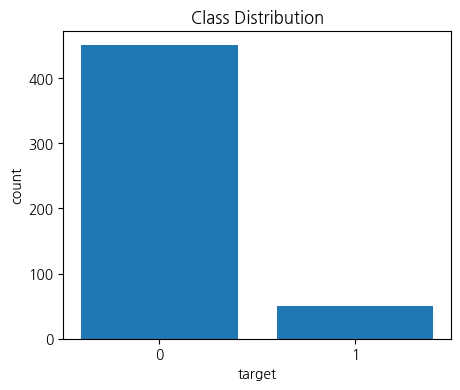

In [11]:
# 시각화
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np

class_counts= df['target'].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel('target')
plt.ylabel('count')
plt.title('Class Distribution')
plt.show()

- **[3] 불균형 데이터 전처리**

In [12]:
## ------------------------------------
## 클래스별 데이터 분리
## ------------------------------------

## => target== 0, target== 1
mask= df['target']== 0
majorDF= df[mask]
minorDF= df[~mask]

print(f' [Major Class] {majorDF.shape}, [Minor Class] {minorDF.shape}')

 [Major Class] (450, 7), [Minor Class] (50, 7)


In [13]:
## ------------------------------------
## Upsampling: 소수 클래스-> 증가
            #  복원 방식 샘플링 즉, 동일 데이터가 계속 추출
# 단점: 동일 데이터 존재=> 과대적합 가능성
## ------------------------------------


minorUpDF= resample(minorDF, 
         replace=True, 
         n_samples= majorDF.shape[0], 
         random_state= 10)


print(f'[Minor Class] {minorDF. shape} => [minorUpDF] {minorUpDF. shape} ')


## MajorDF와 합치기
totalDF = pd.concat([majorDF, minorUpDF])

print(f'[totalDF] {totalDF. shape} ')

print(f' [totalDF] {totalDF. shape} ')
print(f'[Target ] {totalDF["target"].value_counts()} ')


NameError: name 'resample' is not defined

In [11]:
## ======================================
## DownSampling : 메인 클래스 => 감소
#  비복원방식 샘플링 즉, 일부 데이터만 추출
#  - 단점 : 데이터 손실
## ======================================


majorDownDF= resample(majorDF, 
         replace=False, ## 비복원
         n_samples= minorDF.shape[0], ## 소수 클래스 개수만큼 
         random_state= 10)


print(f'[majorDF Class] {majorDF.shape} => [majorDownDF] {majorDownDF. shape} ')

## MajorDF와 합치기
totalDF = pd.concat([majorDownDF, minorDF])

print(f'[totalDF] {totalDF. shape}')
print(f'[Target ] {totalDF["target"].value_counts()}')


[majorDF Class] (450, 7) => [majorDownDF] (50, 7) 
[totalDF] (100, 7)
[Target ] target
0    50
1    50
Name: count, dtype: int64


In [20]:
## conda 패키지 설치
# %conda install -c conda-forge imbalanced-learn -y

In [16]:
## -----------------------------------------------------
## SMOTE : 소수 클래스 -> 증가 즉, UpSampling
## 소수 클래스의 데이터와 비슷하게 새로운 데이터 생성
## - 단점 : 과적합 위험이 존재
## -----------------------------------------------------
from imblearn.over_sampling import SMOTE

## 피쳐와 타겟 분리
featureDF = df[df. columns [ :- 1]]
targetSR = df[df.columns [-1]]
print(f'featureDF : {featureDF. shape}, targetSR : {targetSR. shape} ')
print(f'targetSR: {targetSR.value_counts()}')


featureDF : (500, 6), targetSR : (500,) 
targetSR: target
0    450
1     50
Name: count, dtype: int64


In [17]:
## 피쳐와 타겟 분리
featureDF = df[df. columns [ :- 1]]
targetSR = df[df. columns [-1]]

In [15]:
## --------------------------------------------
## 학습용 | 테스트용 데이터셋 준비
## --------------------------------------------

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(featureDF,
                                                    targetSR,
                                                    test_size=0.2,
                                                    random_state=10,
                                                    stratify=targetSR)


print(f'학습용 : {X_train.shape}, {y_train.shape}')
print(f'테스트용 : {X_test.shape}, {y_test.shape}')

print('\n학습용 클래스 데이터 구성')
print(y_train.value_counts())

print('\n테스트용 클래스 데이터 구성')
print(y_test.value_counts())

display(featureDF.describe(include='all'))


# 서울 대전 대구 부산 제주 광주


학습용 : (400, 6), (400,)
테스트용 : (100, 6), (100,)

학습용 클래스 데이터 구성
target
0    360
1     40
Name: count, dtype: int64

테스트용 클래스 데이터 구성
target
0    90
1    10
Name: count, dtype: int64


,city,grade,gender,age,visit_count,avg_price
count,500,500,500,500.000000,500.000000,500.000000
unique,6,4,2,NaN,NaN,NaN
top,서울,Bronze,Female,NaN,NaN,NaN
freq,179,238,276,NaN,NaN,NaN
mean,NaN,NaN,NaN,42.016000,4.896000,183239.574000
std,NaN,NaN,NaN,13.235032,2.042922,100343.456969
min,NaN,NaN,NaN,20.000000,1.000000,10515.000000
25%,NaN,NaN,NaN,30.750000,4.000000,97883.250000
50%,NaN,NaN,NaN,41.500000,5.000000,184750.000000
75%,NaN,NaN,NaN,54.000000,6.000000,267398.250000


- **전처리**


In [18]:

## => 전처리별 컬럼명
str_cols, sord_cols, num_cols = df.columns[:3:2], df.columns[[1]], df.columns[3 :- 1]

print(f'str_cols: {str_cols}\nsord_cols : {sord_cols}\nnum_cols : {num_cols}')



str_cols: Index(['city', 'gender'], dtype='object')
sord_cols : Index(['grade'], dtype='object')
num_cols : Index(['age', 'visit_count', 'avg_price'], dtype='object')


In [19]:
## ----------------------------------------------------------------
## 통합 전처리 인스턴스 생성
## - 컬럼별 전처리기 지정
## ----------------------------------------------------------------

preprocessing = ColumnTransformer(
    transformers=[
        ('stdScaler', StandardScaler(), num_cols),
        ('ordEncoder', OrdinalEncoder(), sord_cols),
        ('ohEncoder', OneHotEncoder(), str_cols)
    ]
)

preprocessing

ColumnTransformer(transformers=[('stdScaler', StandardScaler(),
                                 Index(['age', 'visit_count', 'avg_price'], dtype='object')),
                                ('ordEncoder', OrdinalEncoder(),
                                 Index(['grade'], dtype='object')),
                                ('ohEncoder', OneHotEncoder(),
                                 Index(['city', 'gender'], dtype='object'))])

In [20]:
## 파이프라인 모듈 로딩
from sklearn.pipeline import Pipeline

## 인스턴스 생성
pipe = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('kModel', KNeighborsClassifier())
])

## 학습진행
pipe.fit(X_train, y_train)

## 성능
train_score = pipe.score(X_train, y_train)
test_score = pipe.score(X_test, y_test)

print(f'[Train Score] {train_score}  [Test Score] {test_score}')

[Train Score] 0.905  [Test Score] 0.9


In [17]:
## => .fit(학습용피처, 학습용타깃) : 전처리 연산 준비 진행
preprocessing.fit(X_train, y_train)



## 데이터 기반 준비된 모델 파라메터들
print(f'feature_names_in_  : {preprocessing.feature_names_in_}')
print(f'named_transformers_: {preprocessing.named_transformers_}')
print(f'transformers_      : {preprocessing.transformers_}')
print(f'output_indices_    : {preprocessing.output_indices_}')

feature_names_in_  : ['city' 'grade' 'gender' 'age' 'visit_count' 'avg_price']
named_transformers_: {'stdScaler': StandardScaler(), 'ordEncoder': OrdinalEncoder(), 'ohEncoder': OneHotEncoder()}
transformers_      : [('stdScaler', StandardScaler(), Index(['age', 'visit_count', 'avg_price'], dtype='object')), ('ordEncoder', OrdinalEncoder(), Index(['grade'], dtype='object')), ('ohEncoder', OneHotEncoder(), Index(['city', 'gender'], dtype='object'))]
output_indices_    : {'stdScaler': slice(0, 3, None), 'ordEncoder': slice(3, 4, None), 'ohEncoder': slice(4, 12, None), 'remainder': slice(0, 0, None)}


In [21]:
## => 전처리 진행 및 변환
X_train_trans = preprocessing. transform(X_train)
X_test_trans = preprocessing. transform(X_test)

## 확인
print(f'X_train.iloc[0] => {X_train.iloc[0].to_list()}')
print(f'X_train_trans[0] => {X_train_trans[0]}')

X_train.iloc[0] => ['대구', 'Gold', 'Female', np.int64(27), np.int64(8), np.int64(328903)]
X_train_trans[0] => [-1.10607255  1.44073464  1.42769065  1.          0.          1.
  0.          0.          0.          0.          1.          0.        ]


- **학습진행**


In [ ]:
## ML 모델 로딩
from sklearn.neighbors import KNeighborsClassifier

## 모델 인스턴스 생성
kModel = KNeighborsClassifier()

## 학습진행
kModel.fit(X_train_trans, y_train)

train_score= kModel.score(X_train_trans, y_train)
test_score= kModel.score(X_test_trans, y_test)

print(f' [Train Score] {train_score} [Test Score] {test_score}')

 [Train Score] 0.905 [Test Score] 0.9
